Laboratorium 11
Franciszek Łasiński
Mini projekt
Klasyfikacja binarna Rozpoznawanie płci (men vs women) z zdjęć

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os
from collections import Counter
from torchvision import models
from torch.utils.tensorboard import SummaryWriter
from torchvision.datasets import ImageFolder

Zrobiłem augumentacje danych obrazów. Dane są ładowane do DataLoaderów, co umożliwia ich wygodne przetwarzanie w trakcie treningu i ewaluacji.

In [ ]:
data_dir = '/Users/franciszeklasinski/Desktop/lab11SSN/gender_dataset'

# Transformacje z augmentacją
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

dataset = datasets.ImageFolder(data_dir, transform=transform)
loader = DataLoader(dataset, batch_size=16, shuffle=True)

class_names = dataset.classes
print("Klasy:", class_names)

Klasy: ['men', 'women']


In [ ]:
# Wyświetlenie kilku obrazów z datasetu
def imshow(img, title=None):
    img = img.numpy()
    img = np.transpose(img, (1, 2, 0))
    img = img * 0.5 + 0.5  
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

Wyświetlanie kilka przykładowych zdjęć z datasetu, zarówno przed jak i po augmentacji. Dzięki temu można zweryfikować, czy dane są poprawnie wczytywane i przetwarzane.

Oryginalne zdjęcia:


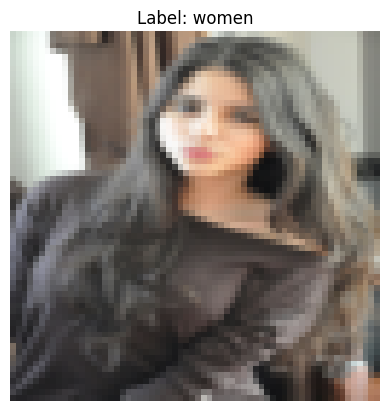

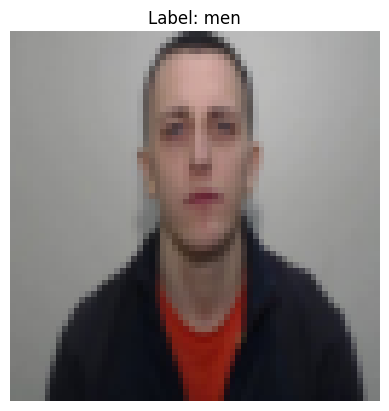

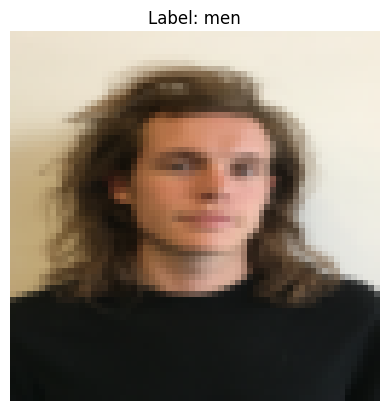

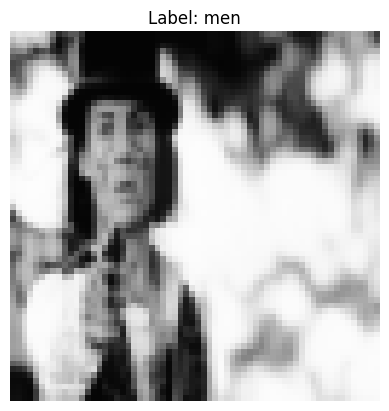

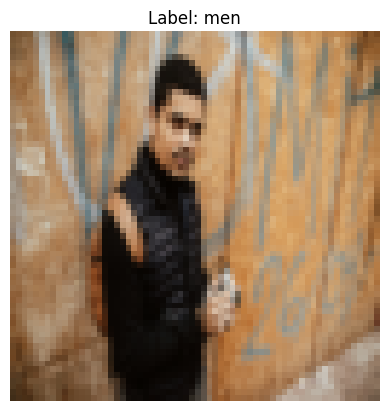

In [ ]:
transform_plain = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

plain_dataset = ImageFolder(data_dir, transform=transform_plain)
plain_loader = DataLoader(plain_dataset, batch_size=16, shuffle=True)

dataiter = iter(plain_loader)
images, labels = next(dataiter)

print("Oryginalne zdjęcia:")
for i in range(5):
    imshow(images[i].cpu(), f"Label: {class_names[labels[i]]}")

Ten fragment kodu zlicza i wypisuje, ile zdjęć znajduje się w każdej klasie

In [ ]:
dataset = datasets.ImageFolder(data_dir)  
class_names = dataset.classes             
labels_list = [label for _, label in dataset.samples]  # Tworzy listę etykiet 0 lub 1 dla każdego obrazu
counts = Counter(labels_list)             # Liczy ile jest obrazów każdej klasy
for idx, count in counts.items():
    print(f"{class_names[idx]}: {count} zdjęć")  

men: 833 zdjęć
women: 835 zdjęć


Zdjęcia po augmentacji:


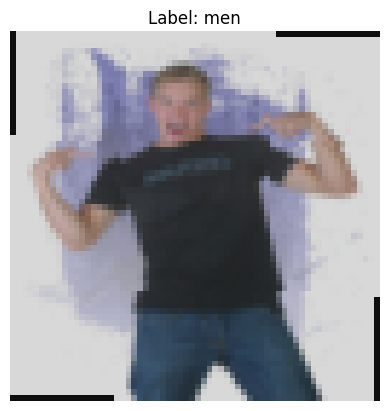

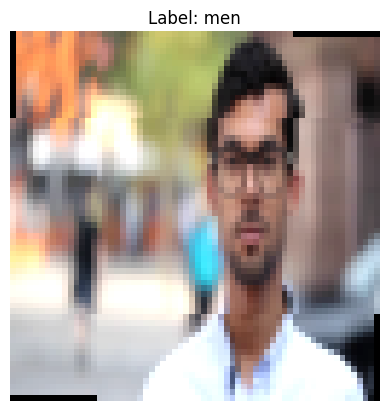

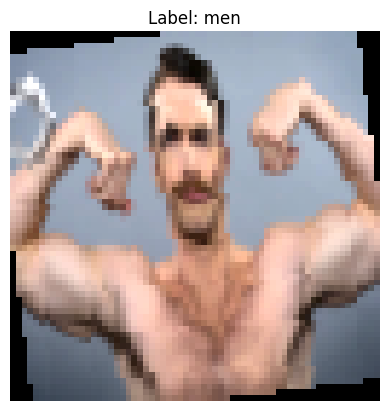

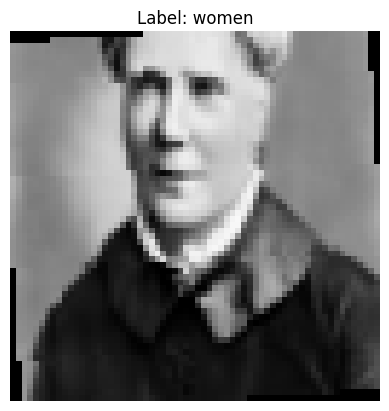

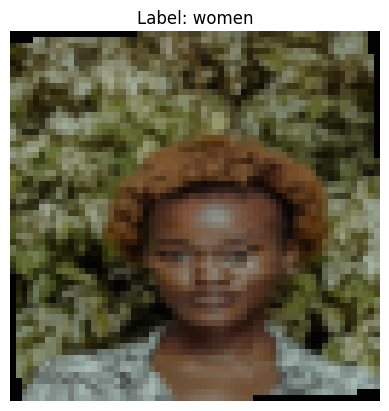

In [ ]:
# Transformacja z augmentacją
transform_aug = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

aug_dataset = datasets.ImageFolder(data_dir, transform=transform_aug)
aug_loader = DataLoader(aug_dataset, batch_size=16, shuffle=True)

dataiter = iter(aug_loader)
images, labels = next(dataiter)
print("Zdjęcia po augmentacji:")
for i in range(5):
    imshow(images[i].cpu(), f"Label: {class_names[labels[i]]}")

W tej części zdefiniowane są dwie architektury sieci: prosty model SimpleCNN oraz bardziej zaawansowany Model2. Oba modele są przystosowane do klasyfikacji obrazów na dwie klasy. 1 model wziąłem z projektu który działał dosyć podobnie (klasyfikacja binarna).

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),
            nn.Flatten(),
            nn.Linear(128*16*16, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, 2)
        )
    def forward(self, x):
        return self.net(x)


def get_resnet():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc = nn.Linear(model.fc.in_features, 2)
    return model

In [ ]:
class Model2(nn.Module):
    def __init__(self):
        super(Model2, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.25),

            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(0.3),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

Kod ten trenuje prostą sieć SimpleCNN na danych po augmentacji, a następnie ocenia ją na danych bez augmentacji. Wyniki loss i accuracy są zapisywane do TensorBoard oraz wyświetlane na wykresach.


Epoch 1/40 (2%)
  Batch 5/105 (4%)
  Batch 10/105 (9%)
  Batch 15/105 (14%)
  Batch 20/105 (19%)
  Batch 25/105 (23%)
  Batch 30/105 (28%)
  Batch 35/105 (33%)
  Batch 40/105 (38%)
  Batch 45/105 (42%)
  Batch 50/105 (47%)
  Batch 55/105 (52%)
  Batch 60/105 (57%)
  Batch 65/105 (61%)
  Batch 70/105 (66%)
  Batch 75/105 (71%)
  Batch 80/105 (76%)
  Batch 85/105 (80%)
  Batch 90/105 (85%)
  Batch 95/105 (90%)
  Batch 100/105 (95%)
  Batch 105/105 (100%)
SimpleCNN - Train loss: 1.6513, acc: 0.5414 | Val loss: 0.6555, acc: 0.6529

Epoch 2/40 (5%)
  Batch 5/105 (4%)
  Batch 10/105 (9%)
  Batch 15/105 (14%)
  Batch 20/105 (19%)
  Batch 25/105 (23%)
  Batch 30/105 (28%)
  Batch 35/105 (33%)
  Batch 40/105 (38%)
  Batch 45/105 (42%)
  Batch 50/105 (47%)
  Batch 55/105 (52%)
  Batch 60/105 (57%)
  Batch 65/105 (61%)
  Batch 70/105 (66%)
  Batch 75/105 (71%)
  Batch 80/105 (76%)
  Batch 85/105 (80%)
  Batch 90/105 (85%)
  Batch 95/105 (90%)
  Batch 100/105 (95%)
  Batch 105/105 (100%)
SimpleCN

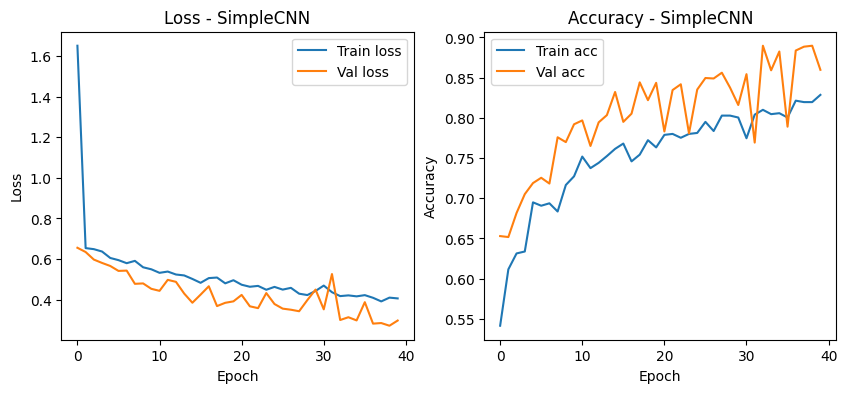

In [ ]:

device = torch.device('mps' if torch.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.CrossEntropyLoss()

cnn = SimpleCNN().to(device)
opt_cnn = torch.optim.Adam(cnn.parameters(), lr=0.0005)
writer = SummaryWriter("runs/gender_classification_cnn")

epochs = 40
train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs} ({int((epoch+1)/epochs*100)}%)")
    cnn.train()
    running_loss, correct, total = 0.0, 0, 0
    num_batches = len(aug_loader)
    for batch_idx, (images, labels) in enumerate(aug_loader):
        images, labels = images.to(device), labels.to(device)
        opt_cnn.zero_grad()
        outputs = cnn(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt_cnn.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == num_batches:
            percent_batch = int((batch_idx + 1) / num_batches * 100)
            print(f"  Batch {batch_idx+1}/{num_batches} ({percent_batch}%)")

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = test(cnn, plain_loader, loss_fn, device)
    print(f"SimpleCNN - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

writer.close()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss - SimpleCNN')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train acc')
plt.plot(val_accs, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy - SimpleCNN')
plt.legend()
plt.show()



Analogicznie do poprzedniej sekcji, tutaj trenowany jest bardziej zaawansowany model Model2. Wyniki treningu i walidacji są logowane i wizualizowane, a na końcu wypisywane są najlepsze osiągnięte metryki.


Epoch 1/60 (1%)
  Batch 5/105 (4%)
  Batch 10/105 (9%)
  Batch 15/105 (14%)
  Batch 20/105 (19%)
  Batch 25/105 (23%)
  Batch 30/105 (28%)
  Batch 35/105 (33%)
  Batch 40/105 (38%)
  Batch 45/105 (42%)
  Batch 50/105 (47%)
  Batch 55/105 (52%)
  Batch 60/105 (57%)
  Batch 65/105 (61%)
  Batch 70/105 (66%)
  Batch 75/105 (71%)
  Batch 80/105 (76%)
  Batch 85/105 (80%)
  Batch 90/105 (85%)
  Batch 95/105 (90%)
  Batch 100/105 (95%)
  Batch 105/105 (100%)
Model2 - Train loss: 0.8713, acc: 0.5288 | Val loss: 0.6567, acc: 0.6097

Epoch 2/60 (3%)
  Batch 5/105 (4%)
  Batch 10/105 (9%)
  Batch 15/105 (14%)
  Batch 20/105 (19%)
  Batch 25/105 (23%)
  Batch 30/105 (28%)
  Batch 35/105 (33%)
  Batch 40/105 (38%)
  Batch 45/105 (42%)
  Batch 50/105 (47%)
  Batch 55/105 (52%)
  Batch 60/105 (57%)
  Batch 65/105 (61%)
  Batch 70/105 (66%)
  Batch 75/105 (71%)
  Batch 80/105 (76%)
  Batch 85/105 (80%)
  Batch 90/105 (85%)
  Batch 95/105 (90%)
  Batch 100/105 (95%)
  Batch 105/105 (100%)
Model2 - Tr

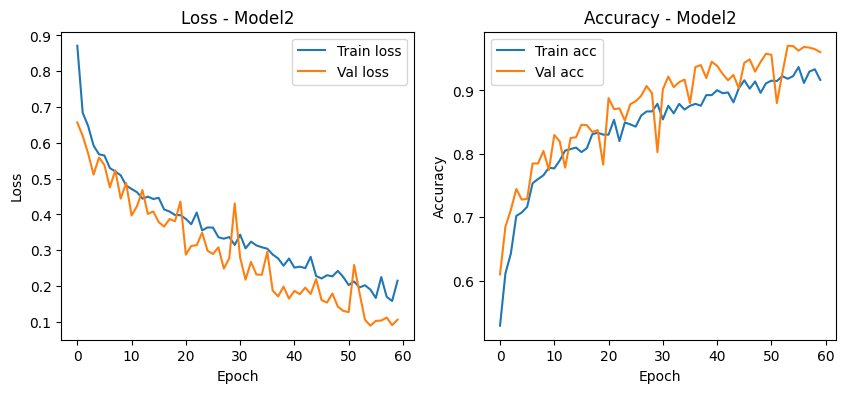


Najlepsze accuracy (val): 97.06%
Najlepszy loss (val): 0.0890
Ostatnia epoka - accuracy (val): 96.04% | loss (val): 0.1059


In [21]:

device = torch.device('mps' if torch.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
loss_fn = nn.CrossEntropyLoss()

advanced_cnn = Model2().to(device)
opt_advanced = torch.optim.Adam(advanced_cnn.parameters(), lr=0.0005)
writer = SummaryWriter("runs/gender_classification_advancedcnn")

epochs = 60
train_losses_adv, val_losses_adv = [], []
train_accs_adv, val_accs_adv = [], []

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs} ({int((epoch+1)/epochs*100)}%)")
    advanced_cnn.train()
    running_loss, correct, total = 0.0, 0, 0
    num_batches = len(aug_loader)
    for batch_idx, (images, labels) in enumerate(aug_loader):
        images, labels = images.to(device), labels.to(device)
        opt_advanced.zero_grad()
        outputs = advanced_cnn(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        opt_advanced.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == num_batches:
            percent_batch = int((batch_idx + 1) / num_batches * 100)
            print(f"  Batch {batch_idx+1}/{num_batches} ({percent_batch}%)")

    train_loss = running_loss / total
    train_acc = correct / total

    val_loss, val_acc = test(advanced_cnn, plain_loader, loss_fn, device)
    print(f"Model2 - Train loss: {train_loss:.4f}, acc: {train_acc:.4f} | Val loss: {val_loss:.4f}, acc: {val_acc:.4f}")

    writer.add_scalar("Loss/train", train_loss, epoch)
    writer.add_scalar("Accuracy/train", train_acc, epoch)
    writer.add_scalar("Loss/val", val_loss, epoch)
    writer.add_scalar("Accuracy/val", val_acc, epoch)

    train_losses_adv.append(train_loss)
    val_losses_adv.append(val_loss)
    train_accs_adv.append(train_acc)
    val_accs_adv.append(val_acc)
writer.close()


plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(train_losses_adv, label='Train loss')
plt.plot(val_losses_adv, label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss - Model2')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs_adv, label='Train acc')
plt.plot(val_accs_adv, label='Val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy - Model2')
plt.legend()
plt.show()

best_val_acc = max(val_accs_adv)
best_val_loss = min(val_losses_adv)
print(f"\nNajlepsze accuracy (val): {best_val_acc*100:.2f}%")
print(f"Najlepszy loss (val): {best_val_loss:.4f}")
print(f"Ostatnia epoka - accuracy (val): {val_accs_adv[-1]*100:.2f}% | loss (val): {val_losses_adv[-1]:.4f}")


Wyniki 2 modeli z tensorboard:


Porównanie 2 modeli:

Oba modele trenowane były na tych samych danych po augmentacji, a ich skuteczność oceniano na niezmodyfikowanych obrazach. Wyniki treningu i walidacji (loss oraz accuracy) były zapisywane do TensorBoard i prezentowane na wykresach. Model2, dzięki głębszej architekturze i większej liczbie parametrów, osiągnął wyższe accuracy na zbiorze walidacyjnym niż SimpleCNN, co oznacza, że lepiej radzi sobie z rozpoznawaniem płci na zdjęciach.

Wyniki:

SimpleCNN - Train loss: 0.4059, acc: 0.8285 | Val loss: 0.2968, acc: 0.8597
Model2    - Train loss: 0.2147, acc: 0.9167 | Val loss: 0.1059, acc: 0.9604

Model SimpleCNN trenowany przez 40 epok osiągnął accuracy na zbiorze walidacyjnym na poziomie 85,97%, przy stracie 0.2968, a cały trening trwał około 60 minut. Bardziej zaawansowany Model2, trenowany przez 60 epok, uzyskał znacznie lepszy wynik – accuracy 96,04% i stratę 0.1059, przy czasie treningu około 75 minut. Wyniki pokazują, że głębsza architektura Model2 pozwala na znacznie skuteczniejszą klasyfikację płci na zdjęciach.

Wnioski końcowe:
W projekcie przeprowadziłem klasyfikację płci na zdjęciach z wykorzystaniem dwóch modeli konwolucyjnych: prostego SimpleCNN oraz bardziej zaawansowanego Model2. Dane treningowe zostały wzbogacone o augmentację, co pozwoliło poprawić zdolność modeli do generalizacji. Wyniki pokazały, że głębszy Model2 osiągnął znacznie wyższą skuteczność niż SimpleCNN, co potwierdza przewagę bardziej złożonych architektur. Cały proces treningu i walidacji był monitorowany za pomocą TensorBoard oraz wykresów w notebooku. Projekt udowadnia, że odpowiednia architektura sieci oraz przygotowanie danych mają kluczowe znaczenie dla skuteczności klasyfikacji obrazów.

In [25]:
%load_ext tensorboard
%tensorboard --logdir runs